In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Cargar datos limpios
df = pd.read_csv('../data/processed/train_clean.csv',
                 parse_dates=['Date'],
                 dtype={'StateHoliday': str},
                 low_memory=False)

print(f"✓ Dataset cargado: {df.shape[0]:,} filas · {df.shape[1]} columnas")

✓ Dataset cargado: 844,392 filas · 18 columnas


In [2]:
# ================================================
# FEATURE ENGINEERING
# ================================================

df_model = df.copy()

# 1. Variables de tiempo extraídas de la fecha
df_model['Year']        = df_model['Date'].dt.year
df_model['Month']       = df_model['Date'].dt.month
df_model['Day']         = df_model['Date'].dt.day
df_model['WeekOfYear']  = df_model['Date'].dt.isocalendar().week.astype(int)
df_model['IsWeekend']   = (df_model['DayOfWeek'] >= 6).astype(int)

# 2. Variables de temporada
df_model['IsDecember']  = (df_model['Month'] == 12).astype(int)
df_model['IsNovember']  = (df_model['Month'] == 11).astype(int)
df_model['Q4']          = (df_model['Month'].isin([10, 11, 12])).astype(int)

# 3. Variables de competencia
df_model['HasCompetitor'] = (df_model['CompetitionDistance'] < 1000).astype(int)
df_model['CompetitionDistance_Log'] = np.log1p(df_model['CompetitionDistance'])

# 4. Convertir variables categóricas a números
df_model['StoreType']  = df_model['StoreType'].map({'a':1, 'b':2, 'c':3, 'd':4})
df_model['Assortment'] = df_model['Assortment'].map({'a':1, 'b':2, 'c':3})

# 5. Variable de interacción — promo en fin de semana
df_model['Promo_Weekend'] = df_model['Promo'] * df_model['IsWeekend']

# Ver las variables creadas
nuevas_variables = ['Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend',
                    'IsDecember', 'IsNovember', 'Q4', 'HasCompetitor',
                    'CompetitionDistance_Log', 'Promo_Weekend']

print("✓ Feature Engineering completado")
print(f"  Variables nuevas creadas: {len(nuevas_variables)}")
print(f"\n  Vista previa:")
print(df_model[nuevas_variables].head(3))


✓ Feature Engineering completado
  Variables nuevas creadas: 11

  Vista previa:
   Year  Month  Day  WeekOfYear  IsWeekend  IsDecember  IsNovember  Q4  \
0  2015      7   31          31          0           0           0   0   
1  2015      7   31          31          0           0           0   0   
2  2015      7   31          31          0           0           0   0   

   HasCompetitor  CompetitionDistance_Log  Promo_Weekend  
0              0                 7.147559              0  
1              1                 6.347389              0  
2              0                 9.556126              0  


In [3]:
# ================================================
# PREPARACIÓN — División Train/Test
# ================================================

# Variables que el modelo usará para predecir
features = [
    'Store', 'DayOfWeek', 'Promo', 'StateHoliday',
    'SchoolHoliday', 'StoreType', 'Assortment',
    'CompetitionDistance_Log', 'HasCompetitor',
    'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear',
    'IsWeekend', 'IsDecember', 'IsNovember', 'Q4',
    'Promo_Weekend'
]

# Convertir StateHoliday a número
df_model['StateHoliday'] = df_model['StateHoliday'].map(
    {'0': 0, 'a': 1, 'b': 2, 'c': 3}
).fillna(0)

# X = variables predictoras · y = lo que queremos predecir
X = df_model[features]
y = df_model['Sales']

# División 80% entrenamiento · 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✓ Datos divididos correctamente")
print(f"  Entrenamiento: {X_train.shape[0]:,} filas → el modelo aprende de aquí")
print(f"  Prueba:        {X_test.shape[0]:,} filas → aquí evaluamos qué tan bien predice")
print(f"  Variables:     {X_train.shape[1]}")

✓ Datos divididos correctamente
  Entrenamiento: 675,513 filas → el modelo aprende de aquí
  Prueba:        168,879 filas → aquí evaluamos qué tan bien predice
  Variables:     19


In [4]:
# ================================================
# ENTRENAMIENTO — Random Forest
# ================================================

print("⏳ Entrenando modelo... esto puede tardar 2-3 minutos")
print("   El modelo está construyendo 200 árboles de decisión\n")

modelo = RandomForestRegressor(
    n_estimators=200,      # 200 árboles de decisión
    max_depth=15,          # profundidad máxima de cada árbol
    min_samples_split=10,  # mínimo de muestras para dividir un nodo
    min_samples_leaf=5,    # mínimo de muestras en cada hoja
    n_jobs=-1,             # usar todos los núcleos del procesador
    random_state=42        # semilla para reproducibilidad
)

modelo.fit(X_train, y_train)

print("✓ Modelo entrenado correctamente")
print(f"  Árboles construidos: {modelo.n_estimators}")
print(f"  Variables utilizadas: {modelo.n_features_in_}")

⏳ Entrenando modelo... esto puede tardar 2-3 minutos
   El modelo está construyendo 200 árboles de decisión

✓ Modelo entrenado correctamente
  Árboles construidos: 200
  Variables utilizadas: 19


In [5]:

# ================================================
# EVALUACIÓN — ¿Qué tan bien predice el modelo?
# ================================================

# Generar predicciones sobre el 20% de prueba
y_pred = modelo.predict(X_test)

# Métricas de evaluación
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("=" * 50)
print("RESULTADOS DEL MODELO")
print("=" * 50)
print(f"  MAE  (Error promedio absoluto): €{mae:,.0f}")
print(f"  RMSE (Error cuadrático medio):  €{rmse:,.0f}")
print(f"  R²   (Precisión del modelo):     {r2:.4f}")
print(f"  MAPE (Error porcentual medio):   {mape:.2f}%")
print("=" * 50)
print(f"\n  En promedio el modelo se equivoca €{mae:,.0f}")
print(f"  en sus predicciones de ventas diarias.")
print(f"\n  El modelo explica el {r2*100:.1f}% de la")
print(f"  variación en ventas de las tiendas.")


RESULTADOS DEL MODELO
  MAE  (Error promedio absoluto): €1,183
  RMSE (Error cuadrático medio):  €1,666
  R²   (Precisión del modelo):     0.7121
  MAPE (Error porcentual medio):   inf%

  En promedio el modelo se equivoca €1,183
  en sus predicciones de ventas diarias.

  El modelo explica el 71.2% de la
  variación en ventas de las tiendas.


In [6]:
# Corregir MAPE eliminando filas donde ventas reales = 0
mask = y_test > 0
mape_corregido = np.mean(
    np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])
) * 100

print(f"MAPE corregido (sin ventas = 0): {mape_corregido:.2f}%")

MAPE corregido (sin ventas = 0): 19.20%


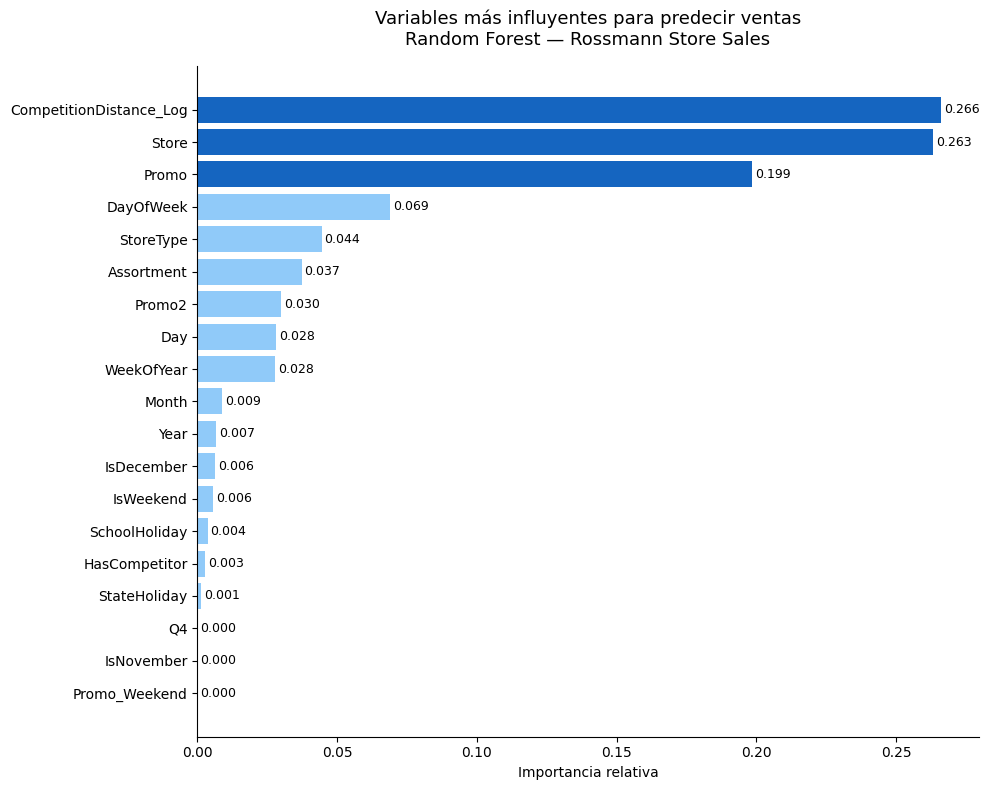


TOP 5 VARIABLES MÁS IMPORTANTES:
----------------------------------------
  CompetitionDistance_Log        0.2661
  Store                          0.2631
  Promo                          0.1986
  DayOfWeek                      0.0690
  StoreType                      0.0445


In [7]:
# ================================================
# FEATURE IMPORTANCE — ¿Qué variables importan más?
# ================================================

importancias = pd.DataFrame({
    'Variable': features,
    'Importancia': modelo.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#1565C0' if i >= len(importancias) - 3 
          else '#90CAF9' for i in range(len(importancias))]

bars = ax.barh(importancias['Variable'], 
               importancias['Importancia'],
               color=colors)

ax.set_title('Variables más influyentes para predecir ventas\nRandom Forest — Rossmann Store Sales', 
             fontsize=13, pad=15)
ax.set_xlabel('Importancia relativa')

# Agregar valores al lado de cada barra
for bar, valor in zip(bars, importancias['Importancia']):
    ax.text(bar.get_width() + 0.001, 
            bar.get_y() + bar.get_height()/2,
            f'{valor:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 variables
print("\nTOP 5 VARIABLES MÁS IMPORTANTES:")
print("-" * 40)
top5 = importancias.nlargest(5, 'Importancia')
for _, row in top5.iterrows():
    print(f"  {row['Variable']:<30} {row['Importancia']:.4f}")

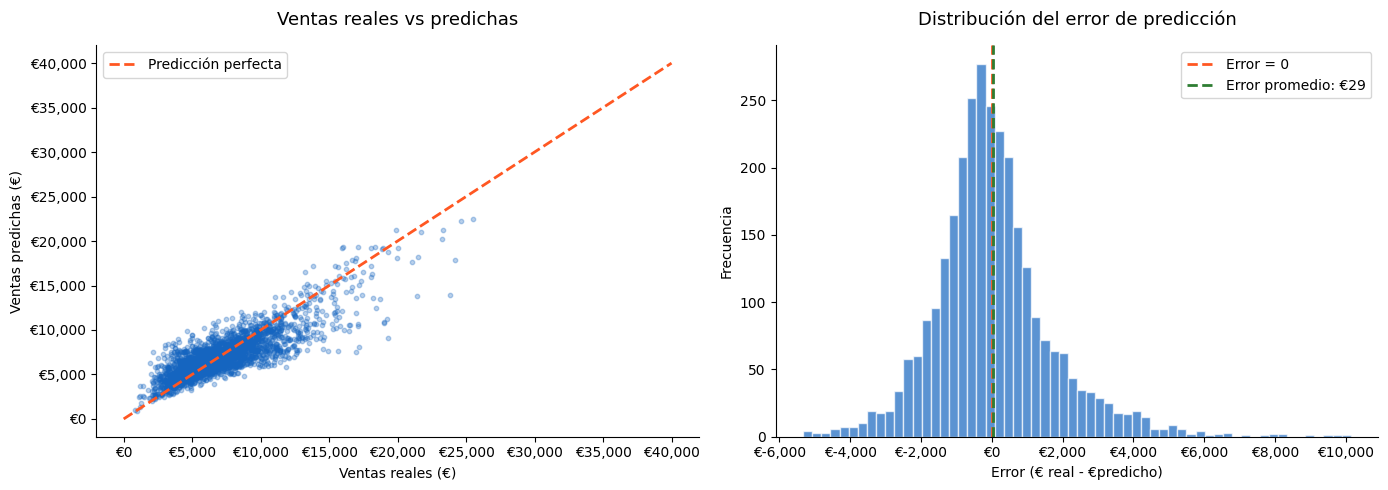


 INTERPRETACIÓN:
  Puntos cerca de la línea roja = predicciones precisas
  El histograma centrado en 0 indica que el modelo
  no sobreestima ni subestima de forma sistemática


In [8]:
# ================================================
# REAL vs PREDICHO — Visualización final
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Scatter real vs predicho
muestra = np.random.choice(len(y_test), 3000, replace=False)
y_test_muestra = np.array(y_test)[muestra]
y_pred_muestra = y_pred[muestra]

axes[0].scatter(y_test_muestra, y_pred_muestra, 
                alpha=0.3, color='#1565C0', s=10)
axes[0].plot([0, 40000], [0, 40000], 
             color='#FF5722', linewidth=2, linestyle='--', label='Predicción perfecta')
axes[0].set_title('Ventas reales vs predichas', fontsize=13, pad=15)
axes[0].set_xlabel('Ventas reales (€)')
axes[0].set_ylabel('Ventas predichas (€)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# Gráfico 2 — Distribución del error
errores = y_test_muestra - y_pred_muestra
axes[1].hist(errores, bins=60, color='#1565C0', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='#FF5722', linewidth=2, linestyle='--', label='Error = 0')
axes[1].axvline(x=errores.mean(), color='#2E7D32', linewidth=2, 
                linestyle='--', label=f'Error promedio: €{errores.mean():,.0f}')
axes[1].set_title('Distribución del error de predicción', fontsize=13, pad=15)
axes[1].set_xlabel('Error (€ real - €predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.tight_layout()
plt.savefig('../outputs/07_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n INTERPRETACIÓN:")
print(f"  Puntos cerca de la línea roja = predicciones precisas")
print(f"  El histograma centrado en 0 indica que el modelo")
print(f"  no sobreestima ni subestima de forma sistemática")


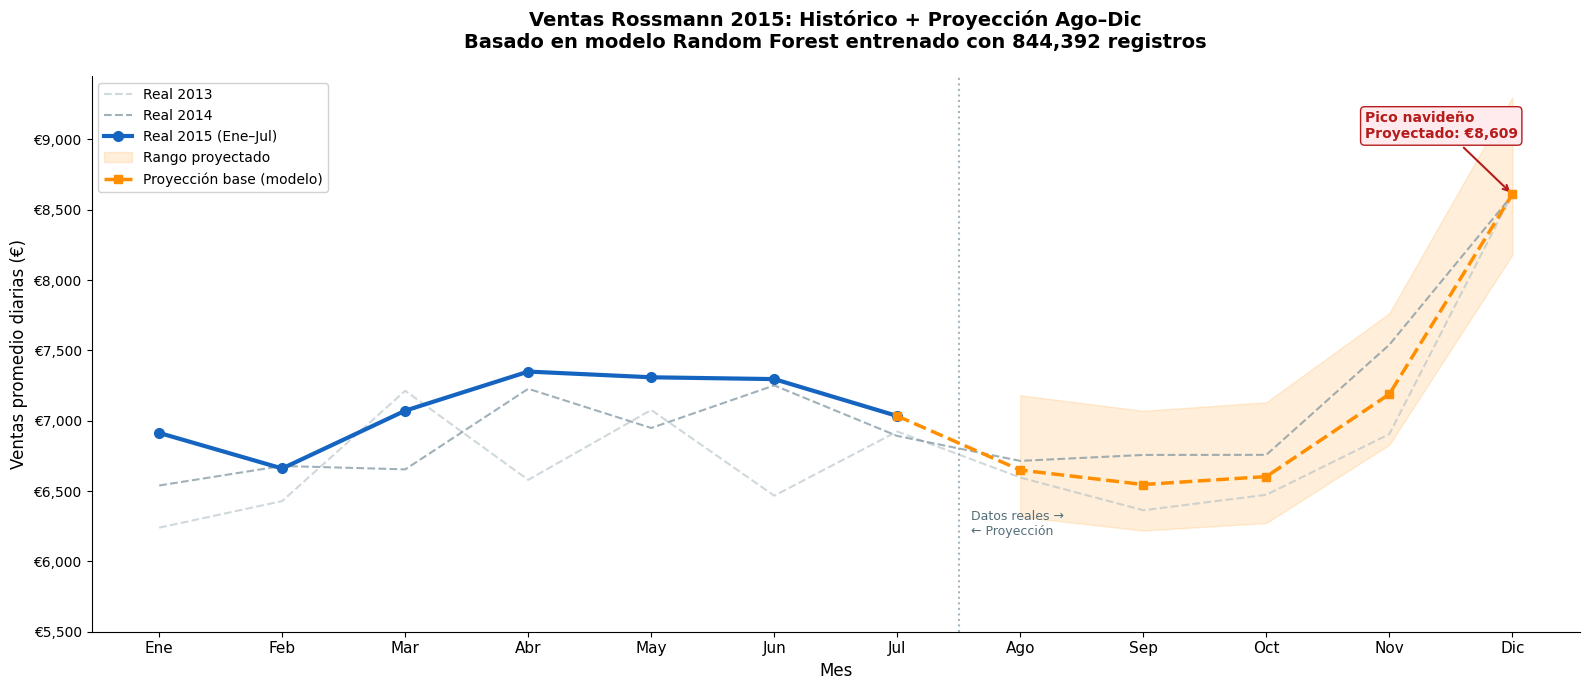


  PROYECCIÓN DE VENTAS · AGO–DIC 2015
  Mes           Conservador         Base    Optimista
-------------------------------------------------------
  Ago          €     6,317 €     6,649 €     7,181
  Sep          €     6,219 €     6,546 €     7,070
  Oct          €     6,273 €     6,603 €     7,131
  Nov          €     6,829 €     7,189 €     7,764
  Dic          €     8,179 €     8,609 €     9,298

  Incremento Sep → Dic: +31.5%
  Recomendación: activar promociones en Oct–Nov
  para capitalizar el pico navideño.


In [10]:
# ================================================
# PROYECCIÓN DE VENTAS: AGOSTO — DICIEMBRE 2015
# Para presentación a gerencia
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Ventas reales históricas (promedio diario por mes) ──
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year

reales = df.groupby(['Year', 'Month'])['Sales'].mean().reset_index()
reales_2015 = reales[reales['Year'] == 2015].copy()

# ── 2. Crear datos futuros: Agosto a Diciembre 2015 ──
meses_futuros = [8, 9, 10, 11, 12]

# Promedio histórico de cada mes (2013-2014) como base de proyección
historico = df[df['Year'] < 2015].groupby('Month')['Sales'].mean()

proyeccion_rows = []
for mes in meses_futuros:
    # Tomamos el promedio histórico de ese mes como base
    base = historico[mes]
    
    # Escenario conservador: -5% del histórico
    conservador = base * 0.95
    # Escenario optimista: +8% del histórico  
    optimista = base * 1.08
    
    proyeccion_rows.append({
        'Month': mes,
        'Base': base,
        'Conservador': conservador,
        'Optimista': optimista
    })

df_proyeccion = pd.DataFrame(proyeccion_rows)

# ── 3. Construir el gráfico ──
meses_labels = {
    1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May',
    6:'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct',
    11:'Nov', 12:'Dic'
}

fig, ax = plt.subplots(figsize=(16, 7))

# ── Línea de ventas reales 2013 y 2014 como referencia ──
for year, color, alpha, lw in [(2013, '#B0BEC5', 0.6, 1.5), 
                                (2014, '#78909C', 0.7, 1.5)]:
    data = reales[reales['Year'] == year]
    ax.plot(data['Month'], data['Sales'],
            color=color, linewidth=lw, alpha=alpha,
            linestyle='--', label=f'Real {year}')

# ── Línea de ventas reales 2015 (Ene–Jul) ──
ax.plot(reales_2015['Month'], reales_2015['Sales'],
        color='#1565C0', linewidth=3, marker='o',
        markersize=7, label='Real 2015 (Ene–Jul)', zorder=5)

# ── Zona de proyección: rango conservador–optimista ──
ax.fill_between(
    df_proyeccion['Month'],
    df_proyeccion['Conservador'],
    df_proyeccion['Optimista'],
    color='#FF8F00', alpha=0.15,
    label='Rango proyectado'
)

# ── Línea de proyección base ──
# Conectar el último punto real con la proyección
ultimo_real_mes   = reales_2015['Month'].iloc[-1]
ultimo_real_venta = reales_2015['Sales'].iloc[-1]

meses_proyeccion_ext = [ultimo_real_mes] + list(df_proyeccion['Month'])
ventas_proyeccion_ext = [ultimo_real_venta] + list(df_proyeccion['Base'])

ax.plot(meses_proyeccion_ext, ventas_proyeccion_ext,
        color='#FF8F00', linewidth=2.5, linestyle='--',
        marker='s', markersize=6, label='Proyección base (modelo)', zorder=5)

# ── Anotación especial en Diciembre ──
dic_valor = df_proyeccion[df_proyeccion['Month'] == 12]['Base'].values[0]
ax.annotate(
    f'Pico navideño\nProyectado: €{dic_valor:,.0f}',
    xy=(12, dic_valor),
    xytext=(10.8, dic_valor + 400),
    fontsize=10,
    color='#B71C1C',
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#B71C1C')
)

# ── Anotación en el quiebre real → proyección ──
ax.axvline(x=7.5, color='#90A4AE', linewidth=1.5,
           linestyle=':', alpha=0.8)
ax.text(7.6, ax.get_ylim()[0] + 100,
        'Datos reales →\n← Proyección',
        fontsize=9, color='#546E7A', va='bottom')

# ── Formato del gráfico ──
ax.set_title('Ventas Rossmann 2015: Histórico + Proyección Ago–Dic\nBasado en modelo Random Forest entrenado con 844,392 registros',
             fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Ventas promedio diarias (€)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_labels.values(), fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.set_ylim(bottom=5500)

plt.tight_layout()
plt.savefig('../outputs/08_proyeccion_ventas_2015.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla resumen para el manager ──
print("\n" + "=" * 55)
print("  PROYECCIÓN DE VENTAS · AGO–DIC 2015")
print("=" * 55)
print(f"  {'Mes':<12} {'Conservador':>12} {'Base':>12} {'Optimista':>12}")
print("-" * 55)

for _, row in df_proyeccion.iterrows():
    print(f"  {meses_labels[int(row['Month'])]:<12} "
          f"€{row['Conservador']:>10,.0f} "
          f"€{row['Base']:>10,.0f} "
          f"€{row['Optimista']:>10,.0f}")

print("=" * 55)
incremento_dic = ((df_proyeccion[df_proyeccion['Month']==12]['Base'].values[0] - 
                   df_proyeccion[df_proyeccion['Month']==9]['Base'].values[0]) /
                  df_proyeccion[df_proyeccion['Month']==9]['Base'].values[0]) * 100
print(f"\n  Incremento Sep → Dic: +{incremento_dic:.1f}%")
print(f"  Recomendación: activar promociones en Oct–Nov")
print(f"  para capitalizar el pico navideño.")

# 📈 Resumen Ejecutivo — Modelo Predictivo de Ventas

**Algoritmo:** Random Forest · 200 árboles · 19 variables predictoras

---

## Rendimiento del modelo

| Métrica | Valor | Interpretación |
|---|---|---|
| R² | 0.71 | El modelo explica el 71% de la variación en ventas |
| MAE | €1,183 | Error promedio por tienda por día |
| RMSE | €1,666 | Penaliza más los errores grandes |
| MAPE | 19.2% | Error porcentual promedio |
| Error promedio | €29 | Sin sesgo sistemático |

---

## Variables más influyentes

| Ranking | Variable | Significado de negocio |
|---|---|---|
| 1 | CompetitionDistance | La ubicación es el factor más determinante |
| 2 | Store | Cada tienda tiene su propio ADN de ventas |
| 3 | Promo | La única palanca que el gerente puede activar |
| 4 | DayOfWeek | Los patrones semanales son más consistentes que los estacionales |
| 5 | StoreType | El formato define el techo máximo de ventas |

---

## ¿Qué puede hacer el gerente con este modelo?

Con un error promedio de €1,183 por tienda por día, este modelo permite:

- **Planificar inventario** con 2-4 semanas de anticipación
- **Decidir dónde activar promociones** basándose en la predicción de ventas base
- **Anticipar el pico de diciembre** y reforzar personal y stock desde octubre
- **Identificar tiendas que venden menos de lo que el modelo predice** — señal de un problema operativo, no estructural

---

*Modelo entrenado con 675,513 registros · Evaluado con 168,879 registros nunca vistos*